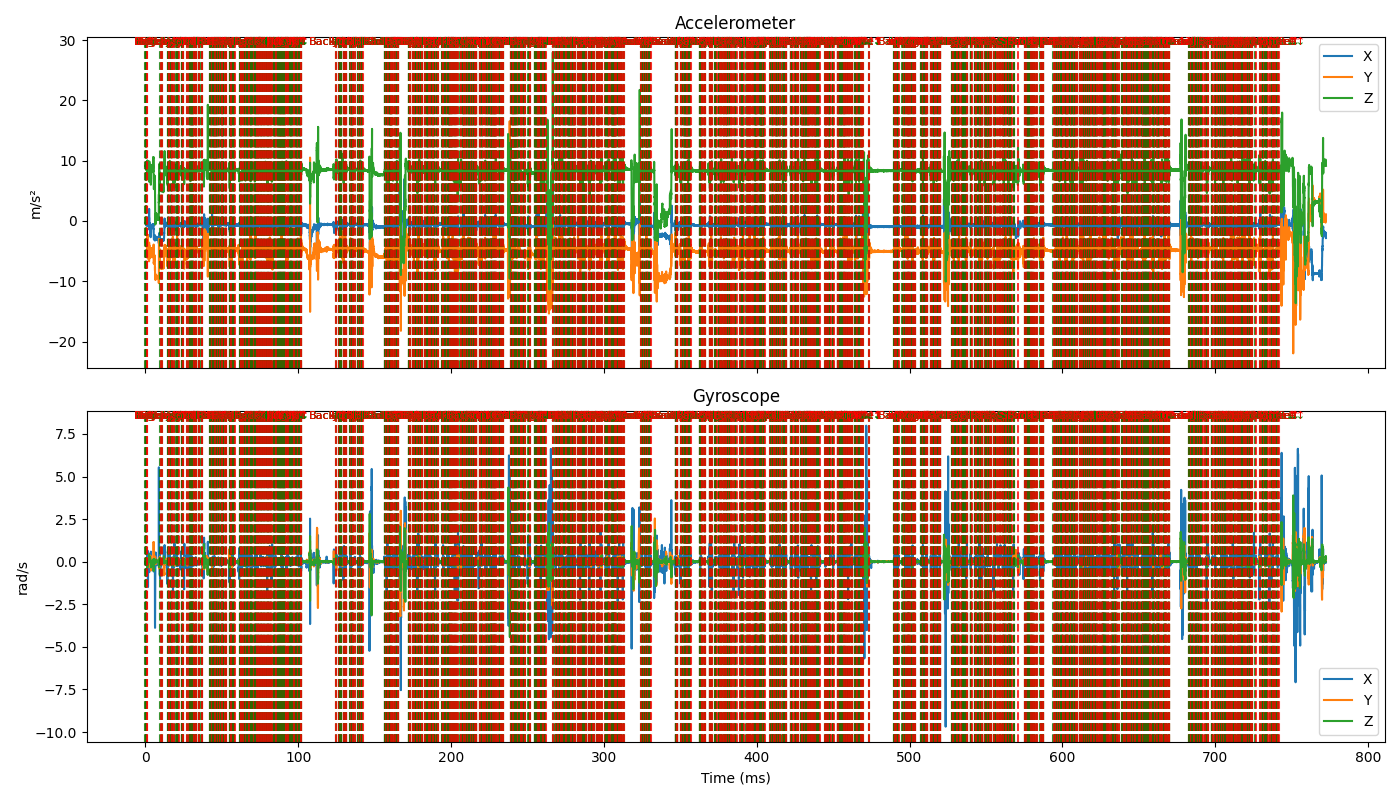

In [2]:
%matplotlib ipympl
import sqlite3, os
import pandas as pd
import matplotlib.pyplot as plt
from DBConfig import DB_HOST, DB_NAME, DB_PASSWORD, DB_PORT, DB_USER, psycopg2


conn = psycopg2.connect(
    dbname=DB_NAME,
    user=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT
)
cursor = conn.cursor()

session_id_db = "31"
# Step 2: Query the session data - SELECTING ONLY USED COLUMNS
# Used: ID, DataFileName, StartKeyID, EndKeyID
session_query = """
SELECT "ID", "DataFileName", "StartKeyID", "EndKeyID"
FROM "Sessions"
WHERE "ID" = %s
"""
cursor.execute(session_query, (session_id_db,))
session_data = cursor.fetchone()

if not session_data:
    raise ValueError(f"Session with ID {session_id_db} not found.")

# Unpack only the 4 columns retrieved
session_id, data_file_name, start_key_id, end_key_id = session_data

# print(f"Session Data (partial): ID={session_id_db}, DataFileName={data_file_name}, StartKeyID={start_key_id}, EndKeyID={end_key_id}")

# Load sensor data
# Ensure 'data_file_name' points to the correct CSV file with the expected columns
df = pd.read_csv(data_file_name, names=['sensor_type', 'timestamp', 'nanoTimestamp', 'x', 'y', 'z'])

# Step 3: Query the keypress data for the session
keypress_query = """
SELECT "KeyDownTimestamp", "KeyUpTimestamp", "KeyPressed", "KeyID"
FROM "KeyPresses"
WHERE "KeyID" BETWEEN %s AND %s
ORDER BY "KeyDownTimestamp"
"""
cursor.execute(keypress_query, (start_key_id, end_key_id,))
keypresses = cursor.fetchall()

# Close the database connection
conn.close()

df = pd.read_csv(data_file_name, names=['sensor_type', 'timestamp', 'nanoTimestamp', 'x', 'y', 'z'])

def save_keystroke_audio(keypresses, df, session_id):
    output_folder = f"SessionsData/KeystrokeData/session_{session_id}"
    os.makedirs(output_folder, exist_ok=True)

    # Convert sensor DataFrame timestamp column to integers (if not already)
    df['timestamp'] = df['timestamp'].astype(int)

    # Reopen DB connection for updates
    conn = psycopg2.connect(
        dbname=DB_NAME,
        user=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT
    )
    cursor = conn.cursor()

    # Iterate over each keystroke and extract corresponding sensor data
    for keydown_ts, keyup_ts, key, key_id in keypresses:
        # Extract sensor data between keydown and keyup
        segment = df[(df['timestamp'] >= keydown_ts) & (df['timestamp'] <= keyup_ts)]
        
        # Save to file
        filename = f"{output_folder}/sensor_{key_id}.csv"
        segment.to_csv(filename, index=False, header=False)

        # Update DB with filename
        update_query = """
        UPDATE "KeyPresses"
        SET "SensorFileName" = %s
        WHERE "KeyID" = %s
        """
        cursor.execute(update_query, (filename, key_id))

    # Commit changes and close DB
    conn.commit()
    conn.close()

save_keystroke_audio(keypresses, df, session_id)
# Normalize time to start from zero (for plotting)
start_time = min(df['timestamp'].min(), min(k[0] for k in keypresses))
df['time_ms'] = (df['timestamp'] - start_time) / 1000.0
keypresses_ms = [((kd - start_time) / 1000.0, (ku - start_time) / 1000.0, key) for kd, ku, key, _ in keypresses]

# Separate accelerometer and gyroscope data
accel_df = df[df['sensor_type'] == 10]
gyro_df = df[df['sensor_type'] == 4]

# Create subplots
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Accelerometer
axs[0].plot(accel_df['time_ms'], accel_df['x'], label='X')
axs[0].plot(accel_df['time_ms'], accel_df['y'], label='Y')
axs[0].plot(accel_df['time_ms'], accel_df['z'], label='Z')
axs[0].set_title("Accelerometer")
axs[0].set_ylabel("m/s²")
axs[0].legend()

# Gyroscope
axs[1].plot(gyro_df['time_ms'], gyro_df['x'], label='X')
axs[1].plot(gyro_df['time_ms'], gyro_df['y'], label='Y')
axs[1].plot(gyro_df['time_ms'], gyro_df['z'], label='Z')
axs[1].set_title("Gyroscope")
axs[1].set_ylabel("rad/s")
axs[1].set_xlabel("Time (ms)")
axs[1].legend()

# Draw start and end lines for keystrokes
for ax in axs:
    for start_ms, end_ms, key in keypresses_ms:
        ax.axvline(x=start_ms, color='green', linestyle='--', alpha=0.8)
        ax.axvline(x=end_ms, color='red', linestyle='--', alpha=0.8)
        ax.text(start_ms, ax.get_ylim()[1], f"{key}↓", ha='center', va='top', fontsize=8, color='green')
        ax.text(end_ms, ax.get_ylim()[1], f"{key}↑", ha='center', va='top', fontsize=8, color='red')

plt.tight_layout()
plt.show()